# Expected Possession Value (EPV) Model

Predicts V(s) = P(score before turnover | current state s) for every throw snapshot.

**Features:**
- `disc_x`, `disc_y` — direction-normalized thrower position
- `throw_idx` — throw number within the possession (capped at 10)
- `prev_throw_dx`, `prev_throw_dy` — direction of the previous throw
- `team_encoded` — team identity

**Label:** 1 if possession scores, 0 if possession turns over

**Models:** XGBoost vs Neural Network (compare, then choose)

In [21]:
#%pip install xgboost

In [22]:
DB_CONFIG = {
    'dbname': 'ufa_analytics',
    'user': os.getenv('DB_USER', 'postgres'),
    'password': '',
    'host': 'localhost',
    'port': 5432
}

conn = psycopg2.connect(**DB_CONFIG, cursor_factory=RealDictCursor)
cur = conn.cursor()

cur.execute("""
    WITH events_norm AS (
        SELECT
            e.event_id,
            e.game_id,
            e.event_number,
            e.event_type,
            e.team,
            CASE WHEN e.team = g.away_team_id THEN -e.thrower_x ELSE e.thrower_x END AS disc_x,
            CASE WHEN e.team = g.away_team_id THEN 120 - e.thrower_y ELSE e.thrower_y END AS disc_y,
            CASE WHEN e.team = g.away_team_id THEN -e.receiver_x ELSE e.receiver_x END AS recv_x,
            CASE WHEN e.team = g.away_team_id THEN 120 - e.receiver_y ELSE e.receiver_y END AS recv_y
        FROM events e
        JOIN games g ON e.game_id = g.game_id
        WHERE e.event_type IN (18, 19, 20, 22)
          AND e.thrower_x IS NOT NULL
          AND e.thrower_y IS NOT NULL
    ),
    events_with_flag AS (
        SELECT *,
            CASE WHEN team IS DISTINCT FROM LAG(team) OVER (PARTITION BY game_id ORDER BY event_number)
                 THEN 1 ELSE 0 END AS team_changed
        FROM events_norm
    ),
    possession_groups AS (
        SELECT *,
            SUM(team_changed) OVER (PARTITION BY game_id ORDER BY event_number) AS poss_id
        FROM events_with_flag
    ),
    -- Quarter boundaries: event types 28/29/30/31 mark Q1/Q2/Q3/Q4 ends
    quarter_boundaries AS (
        SELECT
            game_id,
            MIN(event_number) FILTER (WHERE event_type = 28) AS q2_start,
            MIN(event_number) FILTER (WHERE event_type = 29) AS q3_start,
            MIN(event_number) FILTER (WHERE event_type = 30) AS q4_start
        FROM events
        GROUP BY game_id
    ),
    possession_labels AS (
        SELECT game_id, poss_id,
            MAX(CASE WHEN event_type = 19 THEN 1 ELSE 0 END) AS scored
        FROM possession_groups
        GROUP BY game_id, poss_id
    ),
    throw_snapshots AS (
        SELECT
            pg.game_id, pg.team, pg.disc_x, pg.disc_y, pg.event_type,
            pl.scored,
            LEAST(
                ROW_NUMBER() OVER (PARTITION BY pg.game_id, pg.poss_id ORDER BY pg.event_number),
                10
            ) AS throw_idx,
            COALESCE(
                pg.disc_x - LAG(pg.recv_x) OVER (PARTITION BY pg.game_id, pg.poss_id ORDER BY pg.event_number),
                0
            ) AS prev_throw_dx,
            COALESCE(
                pg.disc_y - LAG(pg.recv_y) OVER (PARTITION BY pg.game_id, pg.poss_id ORDER BY pg.event_number),
                0
            ) AS prev_throw_dy,
            -- Derive quarter from period-end event markers
            CASE
                WHEN pg.event_number < COALESCE(qb.q2_start, 999999) THEN 1
                WHEN pg.event_number < COALESCE(qb.q3_start, 999999) THEN 2
                WHEN pg.event_number < COALESCE(qb.q4_start, 999999) THEN 3
                ELSE 4
            END AS quarter
        FROM possession_groups pg
        JOIN possession_labels pl ON pg.game_id = pl.game_id AND pg.poss_id = pl.poss_id
        LEFT JOIN quarter_boundaries qb ON pg.game_id = qb.game_id
    )
    SELECT disc_x, disc_y, throw_idx, prev_throw_dx, prev_throw_dy, team, quarter, scored
    FROM throw_snapshots
    WHERE disc_x IS NOT NULL AND disc_y IS NOT NULL
""")

rows = cur.fetchall()
cur.close()
conn.close()

df = pd.DataFrame(rows)
print(f'Total throw snapshots: {len(df):,}')
print(f'Scored rate: {df["scored"].mean():.3f}')
print(f'Teams: {df["team"].nunique()}')
print(f'\nQuarter distribution:')
print(df['quarter'].value_counts().sort_index())
print(f'\nThrow index distribution:')
print(df['throw_idx'].value_counts().sort_index())

Total throw snapshots: 412,114
Scored rate: 0.605
Teams: 29

Quarter distribution:
quarter
1    103815
2    102334
3    101975
4    103990
Name: count, dtype: int64

Throw index distribution:
throw_idx
1     57955
2     52648
3     47553
4     41870
5     36289
6     31002
7     26262
8     22083
9     18392
10    78060
Name: count, dtype: int64


In [23]:
team_encoder = LabelEncoder()
df['team_encoded'] = team_encoder.fit_transform(df['team'])

FEATURE_COLS = ['disc_x', 'disc_y', 'throw_idx', 'prev_throw_dx', 'prev_throw_dy', 'team_encoded', 'quarter']

X = df[FEATURE_COLS].values.astype(np.float32)
y = df['scored'].values.astype(np.float32)

X[:, 0] = np.clip(X[:, 0], -25, 25)   # disc_x
X[:, 1] = np.clip(X[:, 1], 0, 120)    # disc_y
X[:, -1] = np.clip(X[:, -1], 1, 4)    # quarter

print(f'Feature matrix: {X.shape}')
print(f'Label distribution: {y.mean():.3f} positive rate')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

Feature matrix: (412114, 7)
Label distribution: 0.605 positive rate
Train: 329,691 | Test: 82,423


## 3. Model A: XGBoost

In [25]:
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    objective='binary:logistic',
    eval_metric='auc',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

xgb_pred = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_pred)
xgb_brier = brier_score_loss(y_test, xgb_pred)

print(f'\nXGBoost AUC-ROC: {xgb_auc:.4f}')
print(f'XGBoost Brier Score: {xgb_brier:.4f}')

[0]	validation_0-auc:0.59773
[50]	validation_0-auc:0.64936
[100]	validation_0-auc:0.65107
[150]	validation_0-auc:0.65175
[193]	validation_0-auc:0.65177

XGBoost AUC-ROC: 0.6518
XGBoost Brier Score: 0.2230


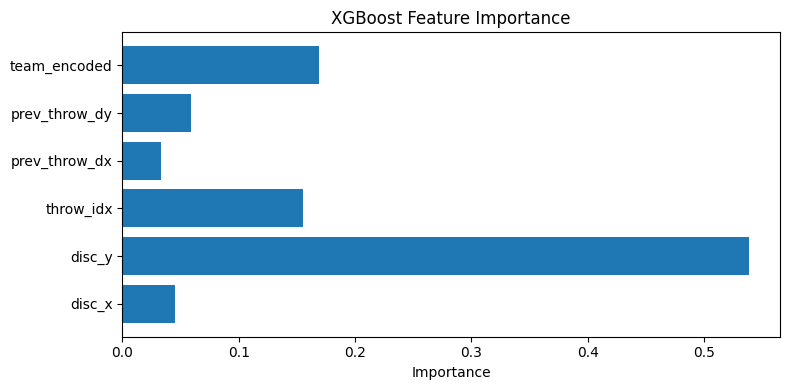

  disc_y: 0.5384
  team_encoded: 0.1694
  throw_idx: 0.1552
  prev_throw_dy: 0.0587
  disc_x: 0.0452
  prev_throw_dx: 0.0331


In [26]:
# Feature importance
importance = xgb_model.feature_importances_
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(FEATURE_COLS, importance)
ax.set_title('XGBoost Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

for col, imp in sorted(zip(FEATURE_COLS, importance), key=lambda x: -x[1]):
    print(f'  {col}: {imp:.4f}')

## 4. Model B: Neural Network

In [27]:
# Scale features for neural net
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

train_ds = TensorDataset(torch.FloatTensor(X_train_scaled), torch.FloatTensor(y_train))
test_ds = TensorDataset(torch.FloatTensor(X_test_scaled), torch.FloatTensor(y_test))
train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=512)

class EPVNet(nn.Module):
    def __init__(self, input_dim=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

nn_model = EPVNet(input_dim=X_train_scaled.shape[1])
optimizer = optim.Adam(nn_model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5, min_lr=1e-6)
criterion = nn.BCELoss()

best_val_loss = float('inf')
best_state = None
patience_counter = 0
train_losses, val_losses = [], []

print(f"{'Epoch':>6} | {'Train':>10} | {'Val':>10}")
print('-' * 32)

for epoch in range(100):
    nn_model.train()
    epoch_loss = 0
    for bx, by in train_loader:
        optimizer.zero_grad()
        loss = criterion(nn_model(bx), by)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_loss = epoch_loss / len(train_loader)
    train_losses.append(train_loss)

    nn_model.eval()
    val_loss = 0
    with torch.no_grad():
        for bx, by in test_loader:
            val_loss += criterion(nn_model(bx), by).item()
    val_loss /= len(test_loader)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = nn_model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        print(f'{epoch+1:6d} | {train_loss:10.5f} | {val_loss:10.5f}')

    if patience_counter >= 15:
        print(f'Early stopping at epoch {epoch+1}')
        break

nn_model.load_state_dict(best_state)
nn_model.eval()

with torch.no_grad():
    nn_pred = nn_model(torch.FloatTensor(X_test_scaled)).numpy()

nn_auc = roc_auc_score(y_test, nn_pred)
nn_brier = brier_score_loss(y_test, nn_pred)
print(f'\nNeural Net AUC-ROC: {nn_auc:.4f}')
print(f'Neural Net Brier Score: {nn_brier:.4f}')

 Epoch |      Train |        Val
--------------------------------
    10 |    0.64033 |    0.64141
    20 |    0.63914 |    0.64092
    30 |    0.63894 |    0.64058
    40 |    0.63821 |    0.64008
    50 |    0.63805 |    0.64017
    60 |    0.63769 |    0.63997
    70 |    0.63754 |    0.63980
    80 |    0.63736 |    0.63975
    90 |    0.63744 |    0.63974
   100 |    0.63733 |    0.63973

Neural Net AUC-ROC: 0.6416
Neural Net Brier Score: 0.2249


## 5. Compare Models

In [28]:
print('=' * 40)
print(f'{'Model':<15} | {'AUC-ROC':>10} | {'Brier':>10}')
print('-' * 40)
print(f'{'XGBoost':<15} | {xgb_auc:>10.4f} | {xgb_brier:>10.4f}')
print(f'{'Neural Net':<15} | {nn_auc:>10.4f} | {nn_brier:>10.4f}')
print('=' * 40)
print('(Higher AUC = better, Lower Brier = better)')

Model           |    AUC-ROC |      Brier
----------------------------------------
XGBoost         |     0.6518 |     0.2230
Neural Net      |     0.6416 |     0.2249
(Higher AUC = better, Lower Brier = better)


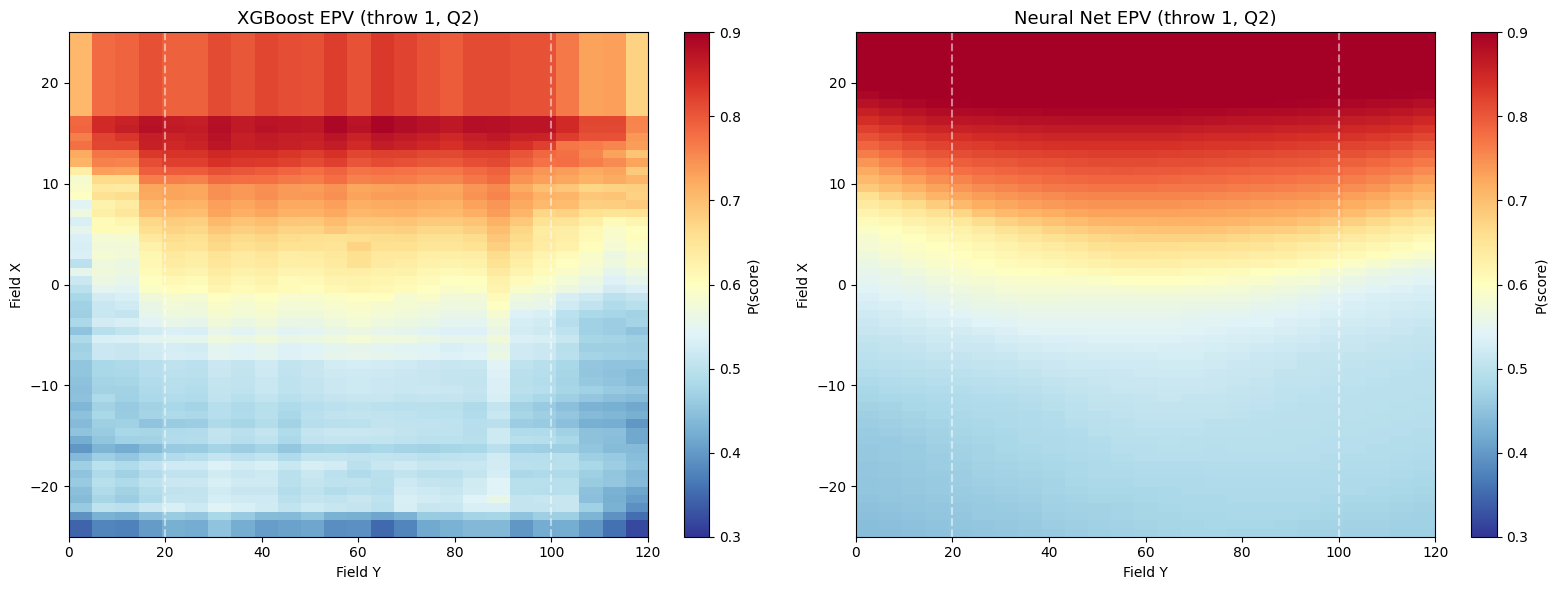

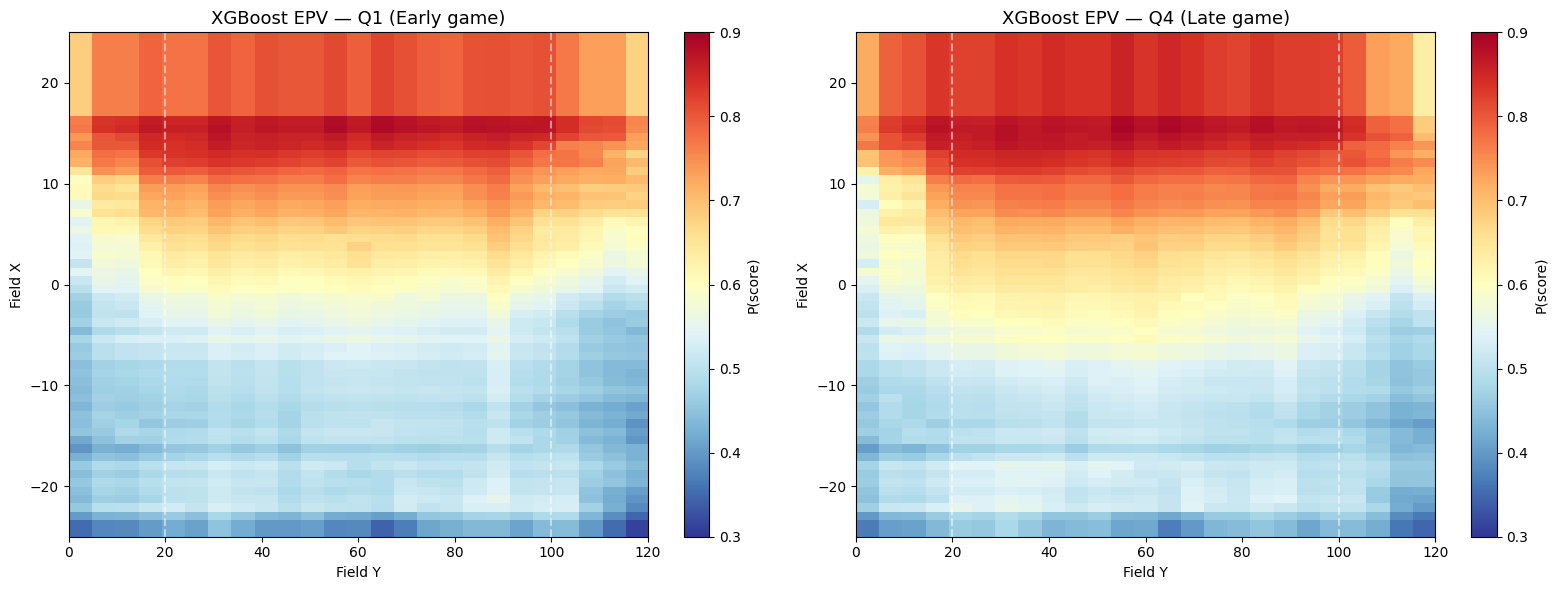

In [41]:
# Visualize EPV field for both models (throw_idx=1, Q2, all teams)
def make_epv_grid(model_type='xgb', throw_idx=1, team_name=None, quarter=2):
    xs = np.linspace(-25, 25, 25)
    ys = np.linspace(0, 120, 60)
    xx, yy = np.meshgrid(xs, ys)  # shape (60, 25)

    team_id = team_encoder.transform([team_name])[0] if team_name else 0

    grid_points = np.column_stack([
        xx.ravel(), yy.ravel(),
        np.full(xx.size, throw_idx),
        np.zeros(xx.size),   # prev_dx
        np.zeros(xx.size),   # prev_dy
        np.full(xx.size, team_id),
        np.full(xx.size, quarter),
    ]).astype(np.float32)

    if model_type == 'xgb':
        probs = xgb_model.predict_proba(grid_points)[:, 1]
    else:
        scaled = scaler.transform(grid_points)
        with torch.no_grad():
            probs = nn_model(torch.FloatTensor(scaled)).numpy()

    return probs.reshape(60, 25)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model_type, title in zip(axes, ['xgb', 'nn'], ['XGBoost EPV', 'Neural Net EPV']):
    grid = make_epv_grid(model_type=model_type, throw_idx=1, quarter=2)
    im = ax.imshow(grid, origin='lower', extent=[0, 120, -25, 25], aspect='auto', cmap='RdYlBu_r', vmin=0.3, vmax=0.9)
    ax.axvline(x=20, color='white', linestyle='--', alpha=0.5)
    ax.axvline(x=100, color='white', linestyle='--', alpha=0.5)
    ax.set_title(f'{title} (throw 1, Q2)', fontsize=13)
    ax.set_xlabel('Field Y')
    ax.set_ylabel('Field X')
    plt.colorbar(im, ax=ax, label='P(score)')

plt.tight_layout()
plt.savefig('epv_comparison.png', dpi=150)
plt.show()

# Show Q1 vs Q4 comparison for XGBoost
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, q, title in zip(axes, [1, 4], ['Q1 (Early game)', 'Q4 (Late game)']):
    grid = make_epv_grid(model_type='xgb', throw_idx=1, quarter=q)
    im = ax.imshow(grid, origin='lower', extent=[0, 120, -25, 25], aspect='auto', cmap='RdYlBu_r', vmin=0.3, vmax=0.9)
    ax.axvline(x=20, color='white', linestyle='--', alpha=0.5)
    ax.axvline(x=100, color='white', linestyle='--', alpha=0.5)
    ax.set_title(f'XGBoost EPV — {title}', fontsize=13)
    ax.set_xlabel('Field Y')
    ax.set_ylabel('Field X')
    plt.colorbar(im, ax=ax, label='P(score)')
plt.tight_layout()
plt.savefig('epv_q1_vs_q4.png', dpi=150)
plt.show()

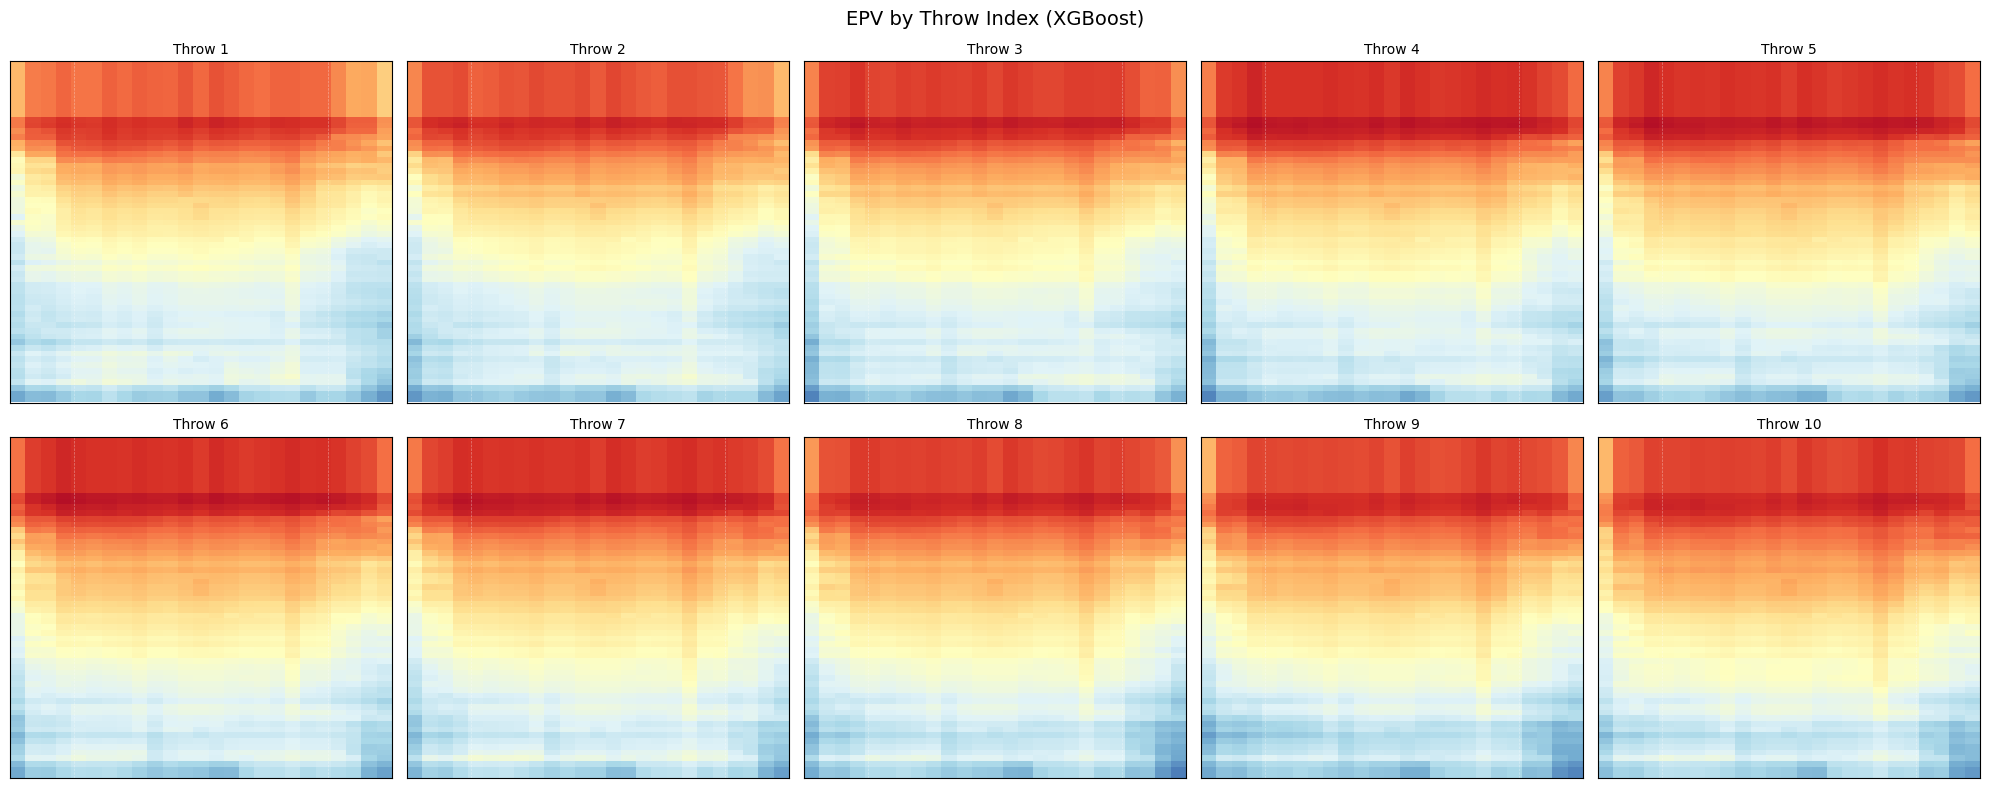

In [42]:
# EPV by throw index for XGBoost
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for idx, ax in enumerate(axes.ravel()):
    throw_idx = idx + 1
    grid = make_epv_grid(model_type='xgb', throw_idx=throw_idx)
    im = ax.imshow(grid, origin='lower', extent=[0, 120, -25, 25], aspect='auto', cmap='RdYlBu_r', vmin=0.2, vmax=0.95)
    ax.axvline(x=20, color='white', linestyle='--', alpha=0.4, linewidth=0.5)
    ax.axvline(x=100, color='white', linestyle='--', alpha=0.4, linewidth=0.5)
    ax.set_title(f'Throw {throw_idx}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('EPV by Throw Index (XGBoost)', fontsize=14)
plt.tight_layout()
plt.savefig('epv_by_throw_idx.png', dpi=150)
plt.show()

In [43]:
os.makedirs('models', exist_ok=True)

input_dim = X_train.shape[1]  # 7 (includes quarter)

# Save XGBoost
joblib.dump({
    'model': xgb_model,
    'team_encoder': team_encoder,
    'feature_cols': FEATURE_COLS,
    'input_dim': input_dim,
    'metrics': {'auc': xgb_auc, 'brier': xgb_brier},
}, 'models/epv_xgb.pkl')
print(f'XGBoost saved ({os.path.getsize("models/epv_xgb.pkl")/1024:.0f} KB)')

# Save Neural Net
joblib.dump({
    'model_state_dict': best_state,
    'scaler': scaler,
    'team_encoder': team_encoder,
    'feature_cols': FEATURE_COLS,
    'input_dim': input_dim,
    'metrics': {'auc': nn_auc, 'brier': nn_brier},
}, 'models/epv_nn.pkl')
print(f'Neural Net saved ({os.path.getsize("models/epv_nn.pkl")/1024:.0f} KB)')
print(f'Input dim: {input_dim} features: {FEATURE_COLS}')

XGBoost saved (1053 KB)
Neural Net saved (48 KB)
Input dim: 7 features: ['disc_x', 'disc_y', 'throw_idx', 'prev_throw_dx', 'prev_throw_dy', 'team_encoded', 'quarter']
